In [2]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer

In [3]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')     # Needed in newer NLTK versions
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv("reviews.csv")
df.head()

,Reviewer,Date,review
0,Joshua C.,"Nov 13, 2013","Like any other Walmart around the country, ""It..."
1,LaTrice T.,"Apr 9, 2021",Wished I could give a very thorough review but...
2,Quinella H.,"Jan 3, 2020",Every month you come here the system broke u c...
3,Brian S.,"Dec 5, 2014",After years of the only chicago Walmart being ...
4,Alecia K.,"Jun 24, 2015",I think it's great to have a Walmart in the Ch...


In [5]:
df = df.dropna(subset=["review"])

df = df[df["review"].str.len() > 5]

In [6]:
stop_words = set(stopwords.words("english"))

In [7]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [8]:
df["clean_review"] = df["review"].apply(clean_text)

In [9]:
def polarity(text):

    return TextBlob(text).sentiment.polarity

df["polarity"] = df["clean_review"].apply(polarity)

In [10]:
def sentiment(score):

    if score > 0.1:
        return "Positive"

    elif score < -0.1:
        return "Negative"

    else:
        return "Neutral"

df["sentiment"] = df["polarity"].apply(sentiment)

In [11]:
df["sentiment"].value_counts()

sentiment
Neutral     30
Negative    20
Positive    13
Name: count, dtype: int64

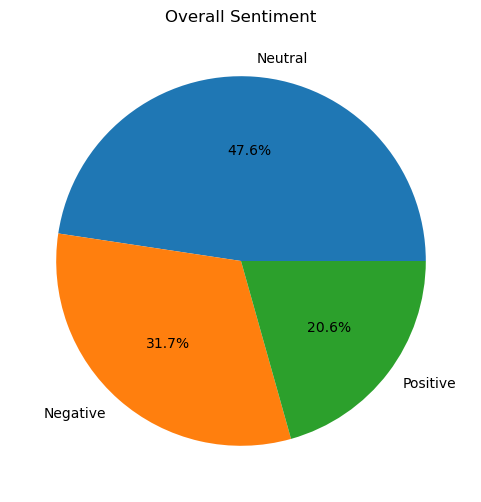

In [12]:
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Overall Sentiment")
plt.show()

In [ ]:
df["polarity"].mean()

-0.04944703114875323


In [16]:
df.head()

,Reviewer,Date,review,clean_review,polarity,sentiment
0,Joshua C.,"Nov 13, 2013","Like any other Walmart around the country, ""It...",like walmart around country dont expect look l...,0.188889,Positive
1,LaTrice T.,"Apr 9, 2021",Wished I could give a very thorough review but...,wished could give thorough review truth didnt ...,-0.050000,Neutral
2,Quinella H.,"Jan 3, 2020",Every month you come here the system broke u c...,every month come system broke u cant never get...,-0.375000,Negative
3,Brian S.,"Dec 5, 2014",After years of the only chicago Walmart being ...,years chicago walmart side town got ta say im ...,0.007576,Neutral
4,Alecia K.,"Jun 24, 2015",I think it's great to have a Walmart in the Ch...,think great walmart chatham community used liv...,0.282197,Positive


In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
df["year"] = df["Date"].dt.year

In [20]:
yearly = df.groupby("year")["polarity"].mean()

In [21]:
yearly_sentiment = (
    df.groupby("year")["polarity"]
      .mean()
      .reset_index()
)

yearly_sentiment

,year,polarity
0,2012,-0.123889
1,2013,0.027953
2,2014,0.004161
3,2015,0.021950
4,2016,0.020766
5,2017,-0.084101
6,2018,-0.118783
7,2019,-0.148842
8,2020,-0.287222
9,2021,-0.200000


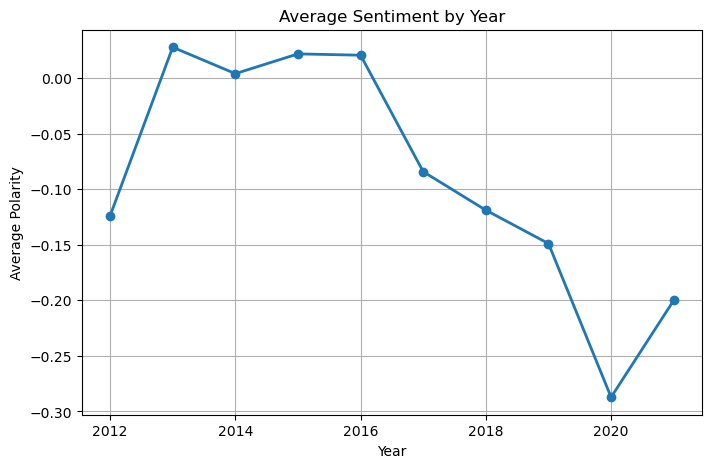

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_sentiment["year"],
    yearly_sentiment["polarity"],
    marker="o",
    linewidth=2
)

plt.title("Average Sentiment by Year")
plt.xlabel("Year")
plt.ylabel("Average Polarity")
plt.grid(True)

plt.show()

In [23]:
sentiment_year = (
    df.groupby(["year","sentiment"])
      .size()
      .reset_index(name="count")
)

sentiment_year

,year,sentiment,count
0,2012,Negative,1
1,2012,Neutral,1
2,2013,Negative,1
3,2013,Neutral,6
4,2013,Positive,3
5,2014,Negative,2
6,2014,Neutral,6
7,2014,Positive,1
8,2015,Negative,1
9,2015,Neutral,4


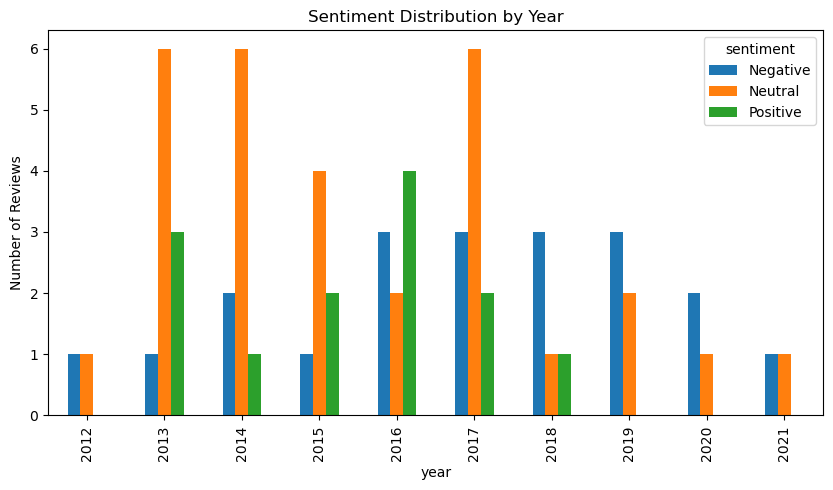

In [24]:
pivot = sentiment_year.pivot(
    index="year",
    columns="sentiment",
    values="count"
).fillna(0)

pivot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Sentiment Distribution by Year")
plt.ylabel("Number of Reviews")
plt.show()

In [25]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
Neutral     30
Negative    20
Positive    13
Name: count, dtype: int64

In [26]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
Neutral     30
Negative    20
Positive    13
Name: count, dtype: int64

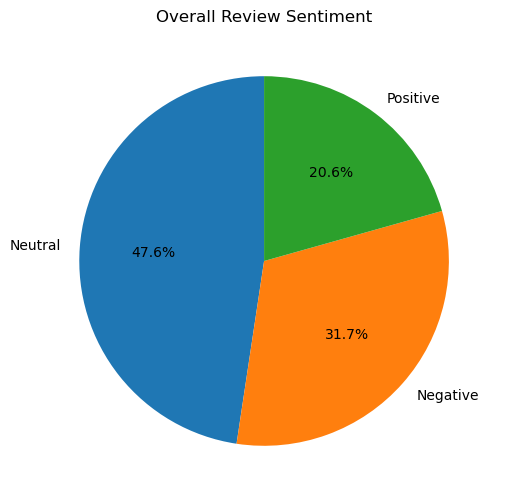

In [27]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Review Sentiment")

plt.show()

In [28]:
average_sentiment = df["polarity"].mean()

print("Average Sentiment:", round(average_sentiment,3))

Average Sentiment: -0.049


In [29]:
reviews_per_year = (
    df.groupby("year")
      .size()
      .reset_index(name="Reviews")
)

reviews_per_year

,year,Reviews
0,2012,2
1,2013,10
2,2014,9
3,2015,7
4,2016,9
5,2017,11
6,2018,5
7,2019,5
8,2020,3
9,2021,2


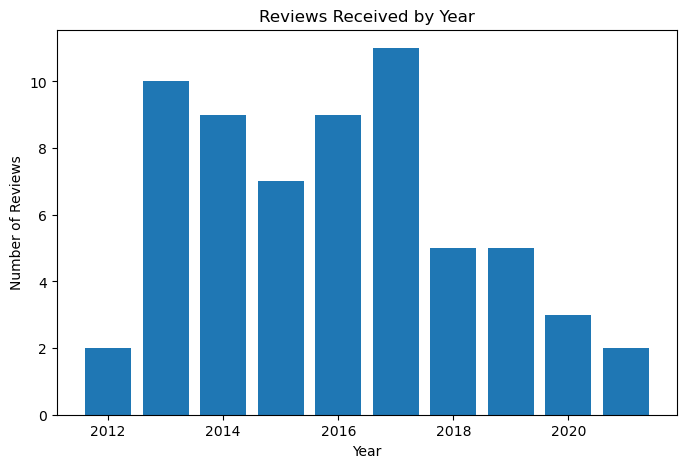

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    reviews_per_year["year"],
    reviews_per_year["Reviews"]
)

plt.title("Reviews Received by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.show()

In [31]:
df.to_csv("reviews_sentiment.csv", index=False)

In [32]:
summary = df.groupby("year").agg(
    AverageSentiment=("polarity","mean"),
    TotalReviews=("review","count"),
    Positive=("sentiment", lambda x: (x=="Positive").sum()),
    Neutral=("sentiment", lambda x: (x=="Neutral").sum()),
    Negative=("sentiment", lambda x: (x=="Negative").sum())
).reset_index()

summary

,year,AverageSentiment,TotalReviews,Positive,Neutral,Negative
0,2012,-0.123889,2,0,1,1
1,2013,0.027953,10,3,6,1
2,2014,0.004161,9,1,6,2
3,2015,0.021950,7,2,4,1
4,2016,0.020766,9,4,2,3
5,2017,-0.084101,11,2,6,3
6,2018,-0.118783,5,1,1,3
7,2019,-0.148842,5,0,2,3
8,2020,-0.287222,3,0,1,2
9,2021,-0.200000,2,0,1,1


In [33]:
summary.to_csv("yearly_sentiment_summary.csv", index=False)

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

In [35]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df["clean_review"])

In [36]:
words = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

word_freq = pd.DataFrame({
    "Word": words,
    "Count": counts
})

word_freq = word_freq.sort_values("Count", ascending=False)

word_freq

,Word,Count
18,walmart,92
16,store,63
15,service,39
2,customer,35
11,location,32
8,like,29
14,people,28
4,dont,26
10,lines,24
6,items,22


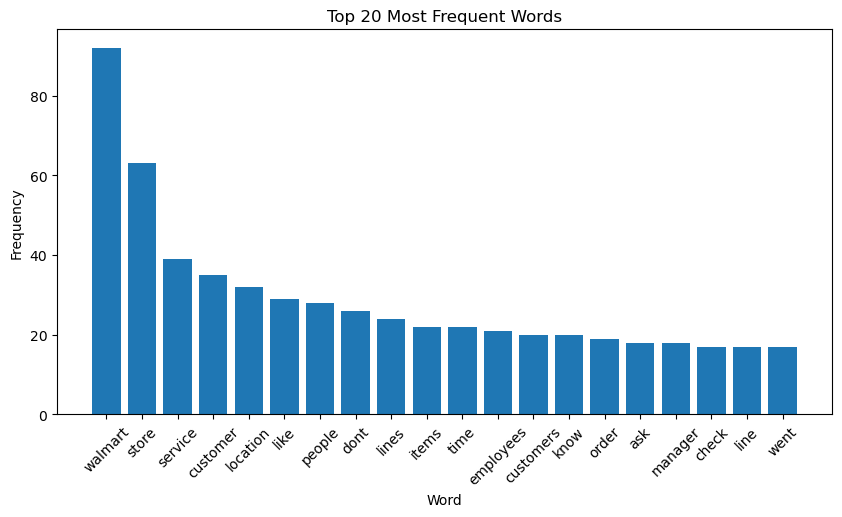

In [37]:
plt.figure(figsize=(10,5))

plt.bar(word_freq["Word"], word_freq["Count"])

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Word")

plt.ylabel("Frequency")

plt.show()

In [38]:
negative_reviews = df[df["sentiment"] == "Negative"]

In [39]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=15
)

X = vectorizer.fit_transform(negative_reviews["clean_review"])

negative_words = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Count": X.sum(axis=0).A1
})

negative_words = negative_words.sort_values(
    "Count",
    ascending=False
)

negative_words

,Word,Count
13,walmart,21
11,store,18
0,customer,12
10,service,12
5,location,11
14,worst,10
12,time,9
3,like,8
7,money,7
8,need,7


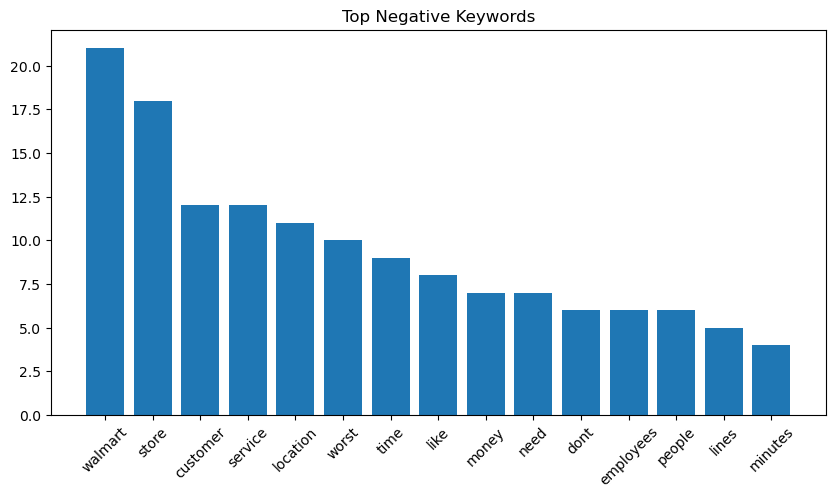

In [40]:
plt.figure(figsize=(10,5))

plt.bar(
    negative_words["Word"],
    negative_words["Count"]
)

plt.xticks(rotation=45)

plt.title("Top Negative Keywords")

plt.show()

In [41]:
positive_reviews = df[df["sentiment"] == "Positive"]

In [42]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=15
)

X = vectorizer.fit_transform(positive_reviews["clean_review"])

positive_words = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Count": X.sum(axis=0).A1
})

positive_words = positive_words.sort_values(
    "Count",
    ascending=False
)

positive_words

,Word,Count
12,walmart,24
10,store,16
7,order,14
3,items,10
4,like,8
6,online,8
8,people,8
9,service,7
14,want,7
5,location,6


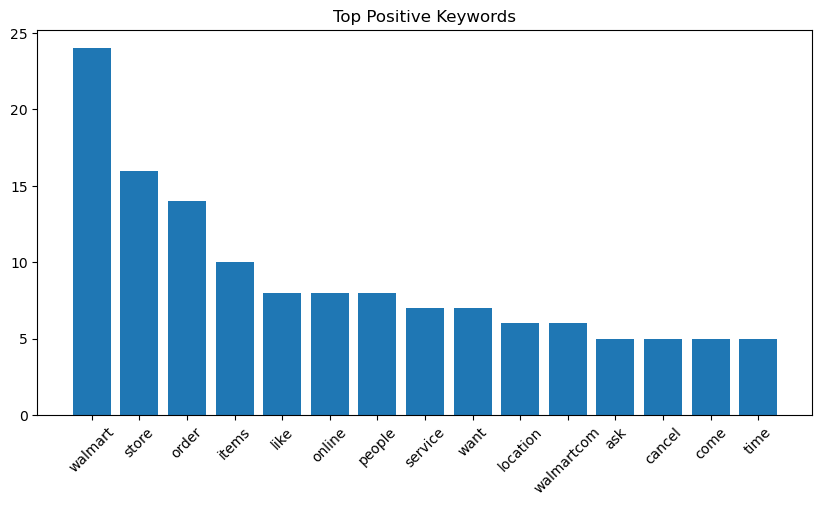

In [43]:
plt.figure(figsize=(10,5))

plt.bar(
    positive_words["Word"],
    positive_words["Count"]
)

plt.xticks(rotation=45)

plt.title("Top Positive Keywords")

plt.show()

In [44]:
word_freq.to_csv("overall_keywords.csv", index=False)

negative_words.to_csv("negative_keywords.csv", index=False)

positive_words.to_csv("positive_keywords.csv", index=False)

In [45]:
aspect_keywords = {
    "Staff": [
        "staff","employee","cashier","manager","service",
        "worker","associate","helpful","rude"
    ],

    "Cleanliness": [
        "clean","dirty","trash","restroom","bathroom",
        "mess","floor","smell"
    ],

    "Checkout": [
        "checkout","register","line","wait",
        "cashier","selfcheckout","queue"
    ],

    "Product Availability": [
        "stock","shelves","empty","inventory",
        "available","items","product","products"
    ],

    "Pricing": [
        "price","prices","expensive","cheap",
        "cost","value"
    ],

    "Parking": [
        "parking","lot","space"
    ]
}

In [46]:
def detect_aspect(review):

    review = review.lower()

    for aspect, words in aspect_keywords.items():

        for word in words:

            if word in review:
                return aspect

    return "Other"

In [47]:
df["Aspect"] = df["clean_review"].apply(detect_aspect)

df[["review","Aspect"]].head()

,review,Aspect
0,"Like any other Walmart around the country, ""It...",Staff
1,Wished I could give a very thorough review but...,Staff
2,Every month you come here the system broke u c...,Staff
3,After years of the only chicago Walmart being ...,Staff
4,I think it's great to have a Walmart in the Ch...,Staff


In [48]:
aspect_sentiment = (
    df.groupby(["Aspect","sentiment"])
      .size()
      .reset_index(name="Count")
)

aspect_sentiment

,Aspect,sentiment,Count
0,Checkout,Negative,3
1,Checkout,Neutral,3
2,Cleanliness,Neutral,1
3,Other,Negative,3
4,Other,Positive,1
5,Pricing,Positive,1
6,Product Availability,Neutral,1
7,Product Availability,Positive,1
8,Staff,Negative,14
9,Staff,Neutral,25


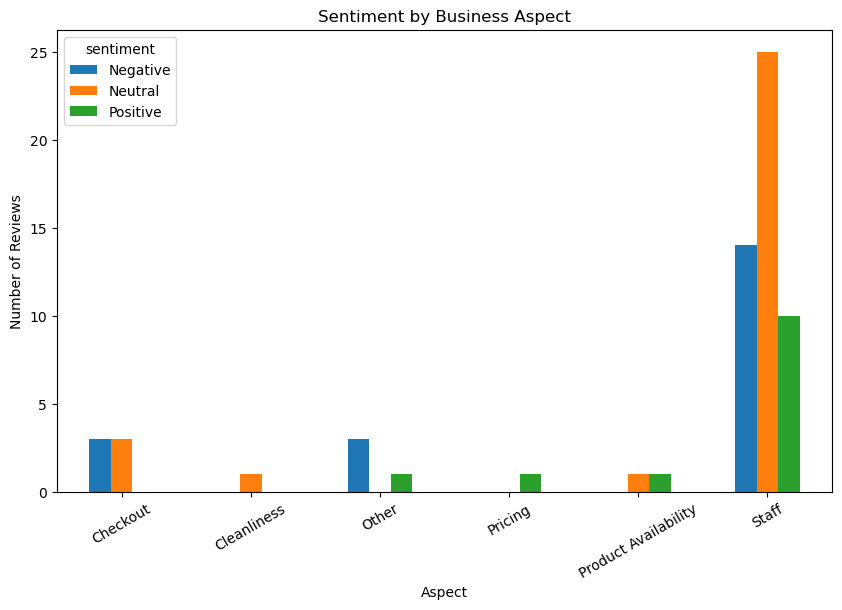

In [49]:
pivot = aspect_sentiment.pivot(
    index="Aspect",
    columns="sentiment",
    values="Count"
).fillna(0)

pivot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sentiment by Business Aspect")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30)

plt.show()

In [50]:
aspect_score = (
    df.groupby("Aspect")["polarity"]
      .mean()
      .reset_index()
      .sort_values("polarity")
)

aspect_score

,Aspect,polarity
2,Other,-0.193403
0,Checkout,-0.133935
5,Staff,-0.040856
1,Cleanliness,0.012500
4,Product Availability,0.150000
3,Pricing,0.151515


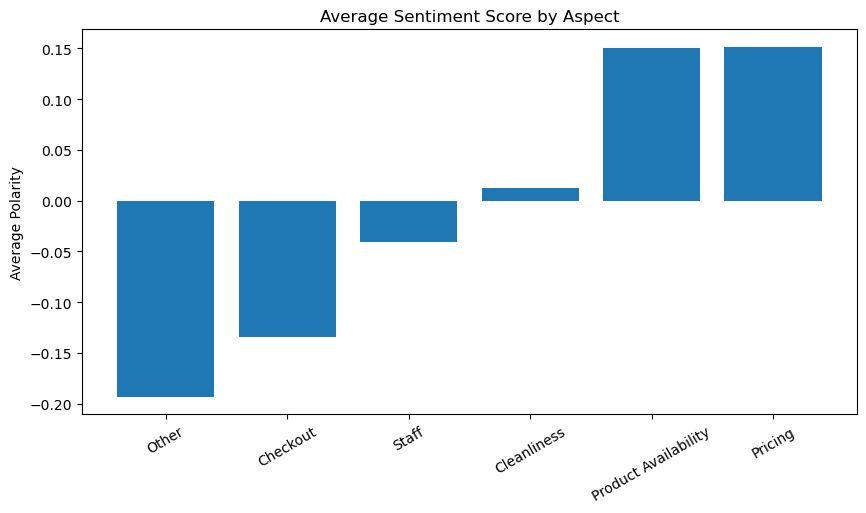

In [51]:
plt.figure(figsize=(10,5))

plt.bar(
    aspect_score["Aspect"],
    aspect_score["polarity"]
)

plt.title("Average Sentiment Score by Aspect")
plt.ylabel("Average Polarity")
plt.xticks(rotation=30)

plt.show()

In [52]:
aspect_sentiment.to_csv(
    "aspect_sentiment.csv",
    index=False
)

aspect_score.to_csv(
    "aspect_scores.csv",
    index=False
)

In [53]:
for _, row in aspect_score.iterrows():

    if row["polarity"] < 0:
        print(f"⚠ {row['Aspect']} received mostly negative feedback.")

    else:
        print(f"✓ {row['Aspect']} received mostly positive feedback.")

⚠ Other received mostly negative feedback.
⚠ Checkout received mostly negative feedback.
⚠ Staff received mostly negative feedback.
✓ Cleanliness received mostly positive feedback.
✓ Product Availability received mostly positive feedback.
✓ Pricing received mostly positive feedback.


In [54]:
top_positive = (
    df.sort_values("polarity", ascending=False)
      [["review", "polarity", "Aspect"]]
      .head(10)
)

top_positive

,review,polarity,Aspect
39,I placed an order and paid for it at this loca...,1.000000,Staff
25,The staff here is super unprofessional ! Just ...,0.333333,Staff
59,"There were no signs of life... no ""FRESH"" food...",0.300000,Product Availability
4,I think it's great to have a Walmart in the Ch...,0.282197,Staff
0,"Like any other Walmart around the country, ""It...",0.188889,Staff
54,Most of the employees spend more time talking ...,0.166833,Staff
7,I frequent the store monthly sometimes twice a...,0.151515,Pricing
18,Everyone loves Walmart including me because th...,0.134615,Staff
8,I would travel to Wal-Mart in Skokie than this...,0.133333,Staff
61,"Wal-Mart Is full of s&%$.Back in the summer, ...",0.120000,Staff


In [55]:
top_positive.to_csv("top_positive_reviews.csv", index=False)

In [56]:
top_negative = (
    df.sort_values("polarity")
      [["review", "polarity", "Aspect"]]
      .head(10)
)

top_negative

,review,polarity,Aspect
38,Horrible customer service. Staff always has na...,-1.000000,Staff
23,Most ignorant place I've ever been. Talk to yo...,-0.500000,Other
53,I'm being generous giving this location ONE St...,-0.450000,Staff
30,"If I could, I would give this location 0 stars...",-0.377381,Staff
2,Every month you come here the system broke u c...,-0.375000,Staff
12,Worst store in the worst chain in America. She...,-0.362500,Checkout
34,this store need to get closed . this disorgani...,-0.350000,Checkout
47,Lazy ghetto employees which lack customer serv...,-0.283333,Staff
15,When this store close in this neighborhood. Do...,-0.280000,Staff
17,Long lines... Every single day! Bad attitudes ...,-0.273810,Staff


In [57]:
top_negative.to_csv("top_negative_reviews.csv", index=False)

In [58]:
aspect_frequency = (
    df["Aspect"]
      .value_counts()
      .reset_index()
)

aspect_frequency.columns = ["Aspect", "Reviews"]

aspect_frequency

,Aspect,Reviews
0,Staff,49
1,Checkout,6
2,Other,4
3,Product Availability,2
4,Pricing,1
5,Cleanliness,1


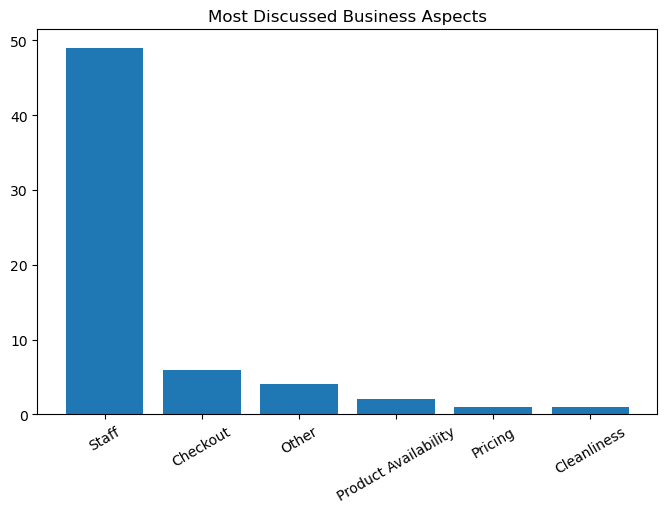

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    aspect_frequency["Aspect"],
    aspect_frequency["Reviews"]
)

plt.xticks(rotation=30)

plt.title("Most Discussed Business Aspects")

plt.show()

In [60]:
positive_percent = (
    (df["sentiment"] == "Positive").mean() * 100
)

negative_percent = (
    (df["sentiment"] == "Negative").mean() * 100
)

neutral_percent = (
    (df["sentiment"] == "Neutral").mean() * 100
)

print(f"Positive: {positive_percent:.1f}%")
print(f"Negative: {negative_percent:.1f}%")
print(f"Neutral : {neutral_percent:.1f}%")

Positive: 20.6%
Negative: 31.7%
Neutral : 47.6%


In [61]:
print("=" * 50)
print("BUSINESS INSIGHTS")
print("=" * 50)

print(f"\nAverage Sentiment Score: {df['polarity'].mean():.2f}")

print(f"\nPositive Reviews : {positive_percent:.1f}%")
print(f"Negative Reviews : {negative_percent:.1f}%")
print(f"Neutral Reviews  : {neutral_percent:.1f}%")

print("\nMost Discussed Aspect:")
print(aspect_frequency.iloc[0]["Aspect"])

print("\nLowest Rated Aspect:")
print(aspect_score.sort_values("polarity").iloc[0]["Aspect"])

print("\nHighest Rated Aspect:")
print(aspect_score.sort_values("polarity", ascending=False).iloc[0]["Aspect"])

BUSINESS INSIGHTS

Average Sentiment Score: -0.05

Positive Reviews : 20.6%
Negative Reviews : 31.7%
Neutral Reviews  : 47.6%

Most Discussed Aspect:
Staff

Lowest Rated Aspect:
Other

Highest Rated Aspect:
Pricing


In [62]:
aspect_frequency.to_csv(
    "aspect_frequency.csv",
    index=False
)

df.to_csv(
    "reviews_dashboard.csv",
    index=False
)

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=20
)

X = bigram_vectorizer.fit_transform(df["clean_review"])

bigram_freq = pd.DataFrame({
    "Bigram": bigram_vectorizer.get_feature_names_out(),
    "Count": X.sum(axis=0).A1
})

bigram_freq = bigram_freq.sort_values(
    "Count",
    ascending=False
)

bigram_freq

,Bigram,Count
3,customer service,28
6,lines long,9
17,went walmart,6
5,dont know,6
10,registers open,4
15,th western,4
16,walmart location,4
19,worst walmart,4
7,long lines,4
2,cash check,4


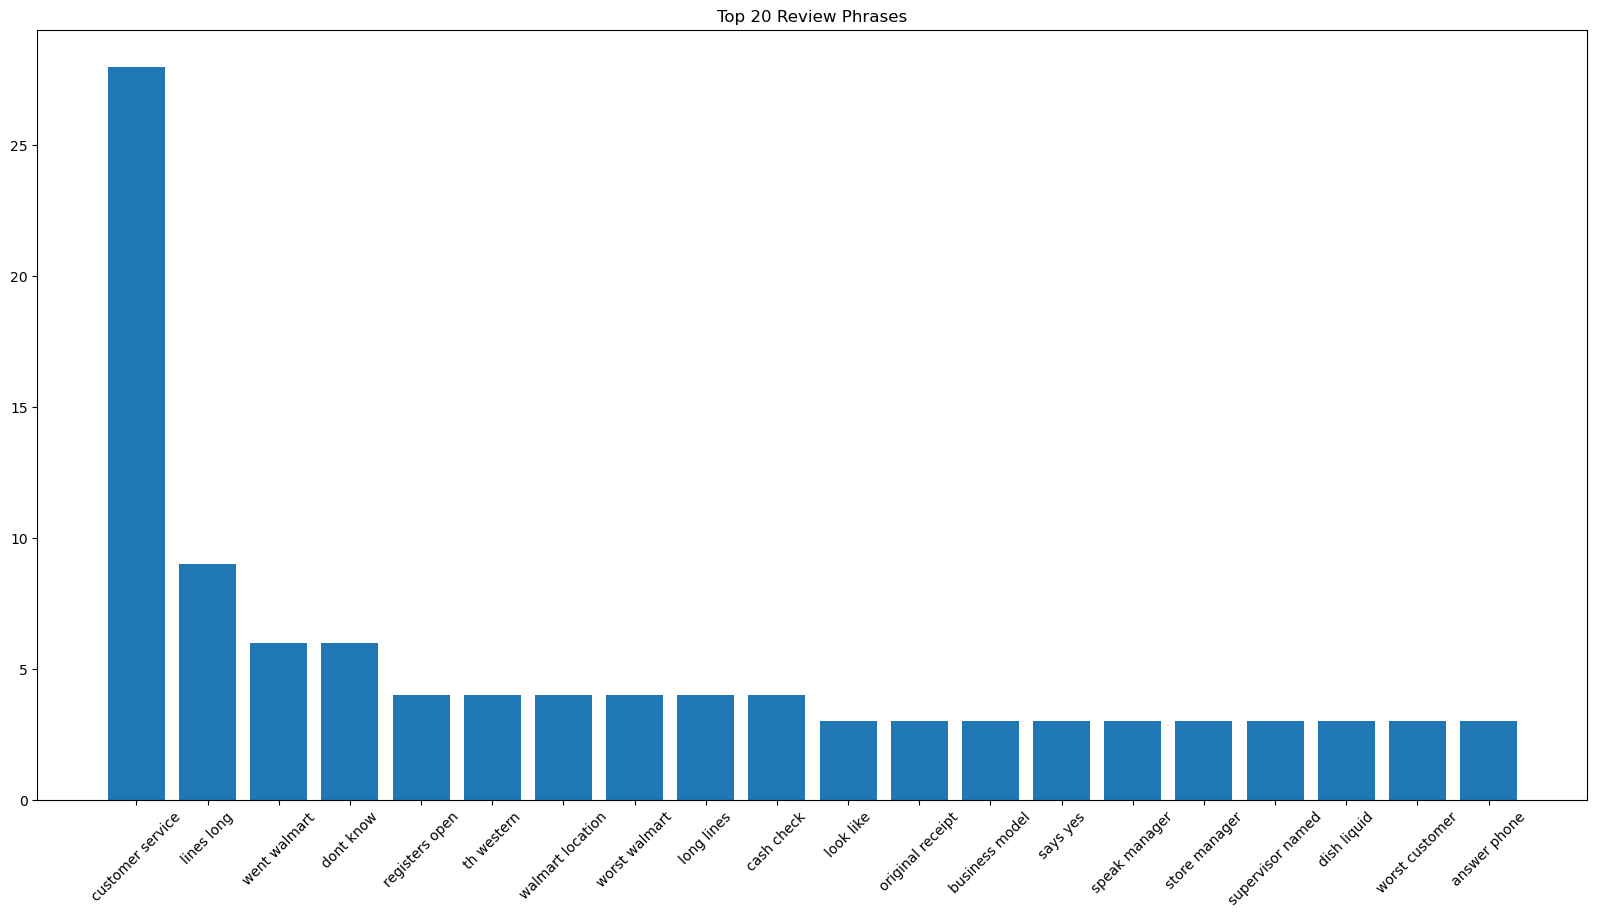

In [66]:
plt.figure(figsize=(20,10))

plt.bar(
    bigram_freq["Bigram"],
    bigram_freq["Count"]
)

plt.xticks(rotation=45)

plt.title("Top 20 Review Phrases")

plt.show()

In [67]:
bigram_freq.to_csv(
    "bigram_keywords.csv",
    index=False
)

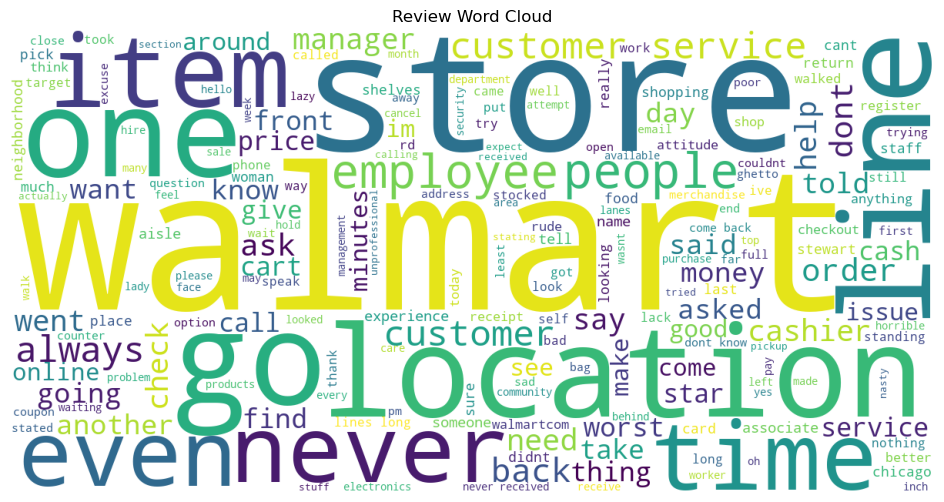

In [68]:
from wordcloud import WordCloud

text = " ".join(df["clean_review"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Review Word Cloud")
plt.show()

In [69]:
negative_text = " ".join(
    df[df["sentiment"]=="Negative"]["clean_review"]
)

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=15
)

X = vectorizer.fit_transform([negative_text])

complaints = pd.DataFrame({
    "Complaint": vectorizer.get_feature_names_out(),
    "Count": X.toarray()[0]
})

complaints = complaints.sort_values(
    "Count",
    ascending=False
)

complaints

,Complaint,Count
2,customer service,10
14,worst walmart,4
13,worst customer,3
0,answer phone,2
1,business model,2
3,lines long,2
4,location needs,2
5,nasty attitudes,2
6,receive email,2
11,speak manager,2


In [70]:
summary = {
    "Total Reviews": len(df),
    "Average Sentiment": round(df["polarity"].mean(), 3),
    "Positive Reviews": int((df["sentiment"]=="Positive").sum()),
    "Neutral Reviews": int((df["sentiment"]=="Neutral").sum()),
    "Negative Reviews": int((df["sentiment"]=="Negative").sum())
}

for key, value in summary.items():
    print(f"{key}: {value}")

Total Reviews: 63
Average Sentiment: -0.049
Positive Reviews: 13
Neutral Reviews: 30
Negative Reviews: 20


In [71]:
summary_df = pd.DataFrame([summary])

summary_df.to_csv(
    "summary.csv",
    index=False
)

In [73]:
summary_df.to_csv("summary.csv")

In [75]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...


True

In [76]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [82]:
df["polarity"] = df["review"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

In [83]:
def classify_sentiment(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [79]:
df["sentiment"] = df["polarity"].apply(classify_sentiment)

In [84]:
df[["review","polarity","sentiment"]].head(10)

,review,polarity,sentiment
0,"Like any other Walmart around the country, ""It...",0.8593,Positive
1,Wished I could give a very thorough review but...,-0.3887,Negative
2,Every month you come here the system broke u c...,-0.3682,Negative
3,After years of the only chicago Walmart being ...,0.4111,Positive
4,I think it's great to have a Walmart in the Ch...,0.9632,Positive
5,The over all layout and organization mirrors o...,-0.7351,Negative
6,This has to be one of the worst Walmart's in t...,0.8835,Positive
7,I frequent the store monthly sometimes twice a...,-0.8237,Positive
8,I would travel to Wal-Mart in Skokie than this...,0.6764,Positive
9,"This store is something else, from the poor cu...",-0.6705,Negative


In [85]:
from textblob import TextBlob

sample_reviews = [
    "Great prices and helpful staff!",
    "Not bad at all.",
    "The checkout was painfully slow.",
    "Absolutely terrible experience."
]

comparison = pd.DataFrame({
    "Review": sample_reviews,
    "TextBlob": [TextBlob(r).sentiment.polarity for r in sample_reviews],
    "VADER": [sia.polarity_scores(r)["compound"] for r in sample_reviews]
})

comparison

,Review,TextBlob,VADER
0,Great prices and helpful staff!,1.00,0.8016
1,Not bad at all.,0.35,0.4310
2,The checkout was painfully slow.,-0.30,-0.5267
3,Absolutely terrible experience.,-1.00,-0.5256


In [86]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

In [87]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(df["clean_review"])

In [88]:
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [89]:
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):

    print(f"\nTopic {topic_idx+1}")

    top_words = [words[i] for i in topic.argsort()[-10:]]

    print(top_words)


Topic 1
['asked', 'customer', 'told', 'know', 'location', 'service', 'items', 'order', 'store', 'walmart']

Topic 2
['worst', 'lines', 'receipt', 'money', 'location', 'time', 'customer', 'service', 'store', 'walmart']

Topic 3
['carts', 'line', 'manager', 'dont', 'cashier', 'cash', 'lines', 'said', 'woman', 'check']

Topic 4
['service', 'dont', 'line', 'customer', 'lines', 'store', 'employees', 'like', 'people', 'walmart']

Topic 5
['looks', 'genius', 'end', 'brand', 'staff', 'service', 'help', 'location', 'customers', 'inch']


In [90]:
topic_matrix = lda.transform(X)

df["Topic"] = topic_matrix.argmax(axis=1) + 1

In [91]:
topic_count = (
    df["Topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topic_count.columns = ["Topic","Reviews"]

topic_count

,Topic,Reviews
0,1,16
1,2,22
2,3,6
3,4,14
4,5,5


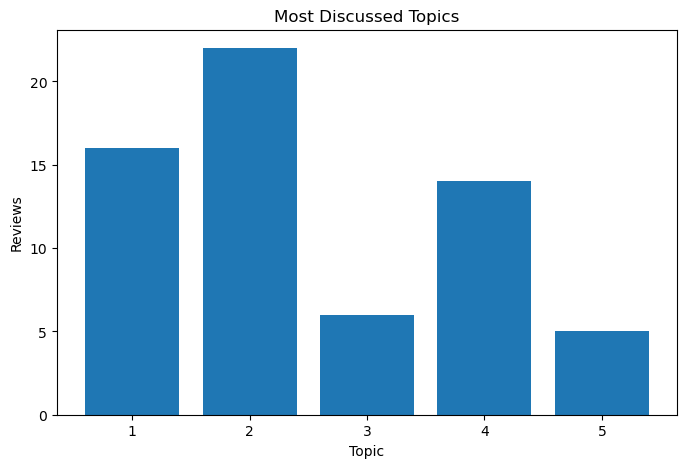

In [92]:
plt.figure(figsize=(8,5))

plt.bar(
    topic_count["Topic"].astype(str),
    topic_count["Reviews"]
)

plt.title("Most Discussed Topics")

plt.xlabel("Topic")

plt.ylabel("Reviews")

plt.show()

In [93]:
topic_count.to_csv(
    "topic_frequency.csv",
    index=False
)

df.to_csv(
    "reviews_with_topics.csv",
    index=False
)